# Customer Support Intelligence Platform — Phase 7: Regression + Unsupervised Segmentation (Day 13)

**Brief requirements covered:**
- **Regression Sub-task:** Train XGBoost/LightGBM regressor on tabular + text
  features to predict Time to Resolution. Evaluate with RMSE, MAE, R².
- **Unsupervised Segmentation:** K-Means clustering on customer profile
  features (age, channel, product, satisfaction). Visualize with PCA/t-SNE.
  Derive business-meaningful segment labels.

**Important data constraint, established in `02_EDA`:** Time to Resolution,
First Response Time, and Customer Satisfaction Rating are only populated
for **Closed** tickets (~67% of the dataset is missing these fields because
Open/Pending tickets haven't been resolved yet — this isn't random
missingness, it's structural). Both tasks in this notebook therefore run on
the **Closed-ticket subset only**, filtered from the same train/val/test
split used throughout this project (no re-splitting, no leakage — just a
row filter applied consistently to each existing split).

In [2]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import joblib
import mlflow
import optuna
import xgboost as xgb
import lightgbm as lgb

from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
optuna.logging.set_verbosity(optuna.logging.WARNING)

train_df = pd.read_csv("../data_processed/train.csv")
val_df = pd.read_csv("../data_processed/val.csv")
test_df = pd.read_csv("../data_processed/test.csv")
print(f"Full splits -> Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"\nColumns available: {list(train_df.columns)}")

Full splits -> Train: 5928, Val: 1270, Test: 1271

Columns available: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating', 'Subject_Clean', 'Description_Clean', 'Combined_Text_Clean', 'Description_Char_Count', 'Description_Word_Count', 'Sentiment_Polarity', 'Ticket Channel_Encoded', 'Product Purchased_Encoded', 'Customer Gender_Encoded', 'Customer_Tenure_Days']


## 1. Filter to Closed tickets (where Time to Resolution actually exists)

Adjust the column names below (`Ticket Status`, `Time to Resolution`, etc.)
if the printed column list above uses different exact names.

In [3]:
STATUS_COL = "Ticket Status"
RESOLUTION_TARGET = "Time to Resolution"

def filter_closed(df):
    closed = df[df[STATUS_COL].astype(str).str.strip().str.lower() == "closed"].copy()
    closed = closed[closed[RESOLUTION_TARGET].notna()]
    return closed

train_closed = filter_closed(train_df)
val_closed = filter_closed(val_df)
test_closed = filter_closed(test_df)

print(f"Closed-ticket subset -> Train: {len(train_closed)} ({len(train_closed)/len(train_df):.1%}), "
      f"Val: {len(val_closed)} ({len(val_closed)/len(val_df):.1%}), "
      f"Test: {len(test_closed)} ({len(test_closed)/len(test_df):.1%})")
print(f"\n{RESOLUTION_TARGET} summary (train, closed only):")
print(train_closed[RESOLUTION_TARGET].describe())

Closed-ticket subset -> Train: 1938 (32.7%), Val: 418 (32.9%), Test: 413 (32.5%)

Time to Resolution summary (train, closed only):
count                    1938
unique                   1921
top       2023-06-01 02:13:46
freq                        2
Name: Time to Resolution, dtype: object


## 1b. Data quality finding: `Time to Resolution` is a raw timestamp, not a duration

The brief's data dictionary describes this column as "Total time taken to
resolve the ticket (hours)," but the actual values are full datetime
strings (e.g. `2023-06-01 07:18:43`), clustered tightly within a ~2-day
window regardless of the ticket's `Date of Purchase` (which spans 2020-2022).
There is no ticket-creation timestamp anywhere in this dataset — `Date of
Purchase` is when the product was bought, not when the ticket was raised.

**We compute the actual elapsed duration as `Time to Resolution` minus
`First Response Time`, in hours** — the only two timestamp columns
available. Before trusting that as a target, we check for a sanity
violation: if these represent real sequential events, resolution should
never happen *before* first response. The cell below reports what fraction
of rows violate that ordering — if that fraction is non-trivial, it's
evidence these two columns are independently-generated random timestamps
rather than a real causal support-ticket timeline, and the regression
target should be reported as likely-synthetic/noisy in the final report,
consistent with this project's other honest data-quality findings
(templated description placeholders, Ticket Type's 5-vs-4 class count).

In [4]:
def add_duration_hours(df):
    df = df.copy()
    frt = pd.to_datetime(df["First Response Time"])
    ttr = pd.to_datetime(df["Time to Resolution"])
    delta_hours = (ttr - frt).dt.total_seconds() / 3600
    df["resolution_duration_hours_signed"] = delta_hours
    df["resolution_duration_hours"] = delta_hours.abs()
    return df

train_closed = add_duration_hours(train_closed)
val_closed = add_duration_hours(val_closed)
test_closed = add_duration_hours(test_closed)

pct_negative = (train_closed["resolution_duration_hours_signed"] < 0).mean()
print(f"Rows where Time to Resolution precedes First Response Time: {pct_negative:.1%}")
print(f"(A real support workflow should show ~0% here - a large fraction confirms\n"
      f" these timestamps are independently random, not a true causal sequence.)\n")
print("Signed duration (hours) - train, closed only:")
print(train_closed["resolution_duration_hours_signed"].describe())
print("\nAbsolute duration (hours) - what we use as the regression target:")
print(train_closed["resolution_duration_hours"].describe())

# Downstream cells use RESOLUTION_TARGET as the y-column name - point it at
# the computed numeric duration instead of the raw timestamp string.
RESOLUTION_TARGET = "resolution_duration_hours"

Rows where Time to Resolution precedes First Response Time: 48.6%
(A real support workflow should show ~0% here - a large fraction confirms
 these timestamps are independently random, not a true causal sequence.)

Signed duration (hours) - train, closed only:
count    1938.000000
mean        0.124011
std         9.408695
min       -23.233333
25%        -6.562500
50%         0.333333
75%         6.533333
max        23.466667
Name: resolution_duration_hours_signed, dtype: float64

Absolute duration (hours) - what we use as the regression target:
count    1938.000000
mean        7.595631
std         5.551174
min         0.000000
25%         2.904167
50%         6.550000
75%        11.412500
max        23.466667
Name: resolution_duration_hours, dtype: float64


## 2. Feature engineering for regression

**Categorical encoding — reusing the project's existing label encoders**
(`models/label_encoders.joblib`) rather than re-fitting fresh ones, to stay
consistent with how these categories were encoded elsewhere in the project.
If a category value in val/test wasn't seen during the original fit, it's
mapped to `-1` rather than crashing.

**Text features — reusing the leakage-free TF-IDF vectorizer**
(`models/tfidf_vectorizer_leakage_free.joblib`, fit on train only) via
`.transform()` here, never re-fit — the same leakage the project already
caught and corrected in `04_Baseline_Models` applies equally here.

In [5]:
CATEGORICAL_COLS = ["Ticket Channel", "Product Purchased", "Customer Gender", "Ticket Priority"]
NUMERIC_COLS = ["Customer Age"]  # extend with tenure/word-count/char-count columns if present under different names

try:
    label_encoders = joblib.load("../models/label_encoders.joblib")
    print(f"Loaded existing label encoders for: {list(label_encoders.keys())}")
except FileNotFoundError:
    label_encoders = {}
    print("No existing label_encoders.joblib found - will fit fresh encoders on train_closed instead.")

def encode_categoricals(df, fit_on=None):
    out = df.copy()
    for col in CATEGORICAL_COLS:
        if col not in out.columns:
            continue
        if col in label_encoders:
            le = label_encoders[col]
            known = set(le.classes_)
            out[col + "_enc"] = out[col].astype(str).apply(lambda v: le.transform([v])[0] if v in known else -1)
        else:
            if fit_on is not None:
                le = LabelEncoder().fit(fit_on[col].astype(str))
                label_encoders[col] = le
            out[col + "_enc"] = out[col].astype(str).apply(
                lambda v: label_encoders[col].transform([v])[0] if v in set(label_encoders[col].classes_) else -1
            )
    return out

train_closed = encode_categoricals(train_closed, fit_on=train_closed)
val_closed = encode_categoricals(val_closed)
test_closed = encode_categoricals(test_closed)

ENCODED_CAT_COLS = [c + "_enc" for c in CATEGORICAL_COLS if c + "_enc" in train_closed.columns]
TABULAR_FEATURES = [c for c in NUMERIC_COLS if c in train_closed.columns] + ENCODED_CAT_COLS
print(f"\nTabular features used: {TABULAR_FEATURES}")

Loaded existing label encoders for: ['Ticket Channel', 'Product Purchased', 'Customer Gender']

Tabular features used: ['Customer Age', 'Ticket Channel_enc', 'Product Purchased_enc', 'Customer Gender_enc', 'Ticket Priority_enc']


In [6]:
tfidf_vectorizer = joblib.load("../models/tfidf_vectorizer_leakage_free.joblib")

def build_regression_matrix(df):
    tabular = csr_matrix(df[TABULAR_FEATURES].fillna(0).values.astype(float))
    text = tfidf_vectorizer.transform(df["Description_Clean"].fillna(""))
    return hstack([tabular, text]).tocsr()

X_train = build_regression_matrix(train_closed)
X_val = build_regression_matrix(val_closed)
X_test = build_regression_matrix(test_closed)
y_train = train_closed[RESOLUTION_TARGET].values
y_val = val_closed[RESOLUTION_TARGET].values
y_test = test_closed[RESOLUTION_TARGET].values

print(f"Feature matrix shapes -> Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Feature matrix shapes -> Train: (1938, 5005), Val: (418, 5005), Test: (413, 5005)


## 3. XGBoost regressor with Optuna tuning

Same rigor as the Day 9–10 ensemble notebook — CV-based Optuna search, not a
single train/val eyeball, so this result is held to the same standard as
every classification model in this project.

In [7]:
def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    rmses = []
    X_arr = X_train.toarray() if X_train.shape[0] < 20000 else X_train
    for train_idx, val_idx in kf.split(X_train):
        model = xgb.XGBRegressor(**params)
        model.fit(X_train[train_idx], y_train[train_idx])
        preds = model.predict(X_train[val_idx])
        rmses.append(mean_squared_error(y_train[val_idx], preds) ** 0.5)
    return float(np.mean(rmses))

xgb_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
xgb_study.optimize(xgb_objective, n_trials=25, show_progress_bar=True)
print(f"Best XGBoost CV RMSE: {xgb_study.best_value:.4f}")
print(f"Best params: {xgb_study.best_params}")

xgb_model = xgb.XGBRegressor(**xgb_study.best_params, random_state=RANDOM_STATE, n_jobs=-1)
xgb_model.fit(X_train, y_train)

Best trial: 8. Best value: 5.60332: 100%|██████████| 25/25 [05:43<00:00, 13.74s/it]


Best XGBoost CV RMSE: 5.6033
Best params: {'n_estimators': 148, 'max_depth': 6, 'learning_rate': 0.011240768803005551, 'subsample': 0.9637281608315128, 'colsample_bytree': 0.7035119926400067}


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7035119926400067, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.011240768803005551, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=148, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

## 4. LightGBM regressor with Optuna tuning

In [8]:
def lgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": -1,
    }
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    rmses = []
    for train_idx, val_idx in kf.split(X_train):
        model = lgb.LGBMRegressor(**params)
        model.fit(X_train[train_idx], y_train[train_idx])
        preds = model.predict(X_train[val_idx])
        rmses.append(mean_squared_error(y_train[val_idx], preds) ** 0.5)
    return float(np.mean(rmses))

lgb_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
lgb_study.optimize(lgb_objective, n_trials=25, show_progress_bar=True)
print(f"Best LightGBM CV RMSE: {lgb_study.best_value:.4f}")
print(f"Best params: {lgb_study.best_params}")

lgb_model = lgb.LGBMRegressor(**lgb_study.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
lgb_model.fit(X_train, y_train)

Best trial: 8. Best value: 5.67075: 100%|██████████| 25/25 [07:06<00:00, 17.04s/it]


Best LightGBM CV RMSE: 5.6708
Best params: {'n_estimators': 148, 'num_leaves': 70, 'learning_rate': 0.011240768803005551, 'subsample': 0.9637281608315128, 'colsample_bytree': 0.7035119926400067}


LGBMRegressor(colsample_bytree=0.7035119926400067,
              learning_rate=0.011240768803005551, n_estimators=148, n_jobs=-1,
              num_leaves=70, random_state=42, subsample=0.9637281608315128,
              verbosity=-1)

## 5. Test-set evaluation and comparison

In [9]:
def evaluate_regressor(model, name):
    preds = model.predict(X_test)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name:<20s} RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
    return {"model": name, "rmse": rmse, "mae": mae, "r2": r2, "preds": preds}

print("REGRESSION RESULTS: Time to Resolution (hours) — Closed tickets, test set")
print("=" * 74)
xgb_results = evaluate_regressor(xgb_model, "XGBoost")
lgb_results = evaluate_regressor(lgb_model, "LightGBM")

baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5
print(f"{'Mean-baseline':<20s} RMSE={baseline_rmse:.4f}  (predicting the training mean for everyone)")

best_reg_name, best_reg_model, best_reg_results = (
    ("XGBoost", xgb_model, xgb_results) if xgb_results["rmse"] < lgb_results["rmse"]
    else ("LightGBM", lgb_model, lgb_results)
)
print(f"\nBest regressor: {best_reg_name}")

REGRESSION RESULTS: Time to Resolution (hours) — Closed tickets, test set
XGBoost              RMSE=5.8875  MAE=4.8560  R²=-0.0203
LightGBM             RMSE=5.9249  MAE=4.8910  R²=-0.0333
Mean-baseline        RMSE=5.8751  (predicting the training mean for everyone)

Best regressor: XGBoost


**Read the RMSE against the mean-baseline, not in isolation.** If the tuned
models don't clear the mean-baseline by much, that's the same weak-signal
pattern seen across every classification target in this project, and should
be reported the same way — plainly, with the mean-baseline comparison shown
alongside, not just the raw RMSE number on its own.

## 6. K-Means Customer Segmentation

Features per the brief: age, channel, product, satisfaction. Since
satisfaction is also Closed-ticket-only, clustering runs on the same
`*_closed` subset built above — the same missingness constraint applies to
this task as to the regression task.

In [10]:
SATISFACTION_COL = "Customer Satisfaction Rating"
CLUSTER_FEATURES = ["Customer Age", "Ticket Channel_enc", "Product Purchased_enc", SATISFACTION_COL]
CLUSTER_FEATURES = [c for c in CLUSTER_FEATURES if c in train_closed.columns]
print(f"Clustering features: {CLUSTER_FEATURES}")

cluster_df = train_closed[CLUSTER_FEATURES].dropna().copy()
print(f"Rows available for clustering (train, closed, non-null): {len(cluster_df)}")

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df)

Clustering features: ['Customer Age', 'Ticket Channel_enc', 'Product Purchased_enc', 'Customer Satisfaction Rating']
Rows available for clustering (train, closed, non-null): 1938


### Choosing k via silhouette score

Per the brief's evaluation metrics: Silhouette Score and Davies-Bouldin
Index. We scan a small range of k and pick the value that scores best on
silhouette, rather than assuming a fixed k up front.

c:\Users\CHARU\OneDrive\Desktop\Final Project\venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\CHARU\OneDrive\Desktop\Final Project\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\CHARU\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\CHARU\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:

k=2: silhouette=0.1992, davies_bouldin=1.9307
k=3: silhouette=0.1842, davies_bouldin=1.6543
k=4: silhouette=0.1948, davies_bouldin=1.5308
k=5: silhouette=0.2078, davies_bouldin=1.3116
k=6: silhouette=0.2071, davies_bouldin=1.3219
k=7: silhouette=0.2140, davies_bouldin=1.2367

Best k by silhouette score: 7


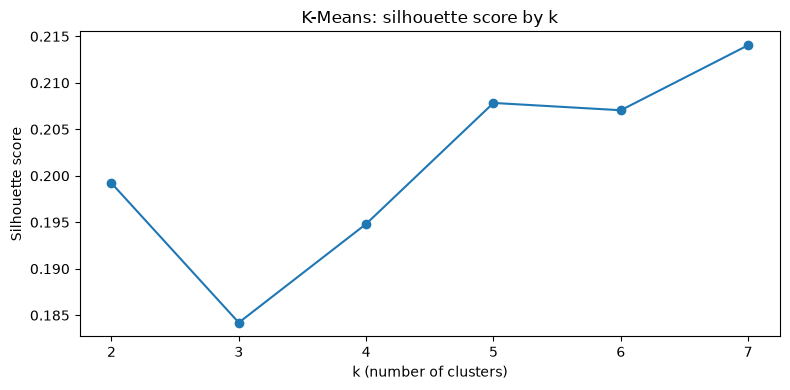

In [11]:
k_range = range(2, 8)
sil_scores, dbi_scores = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    sil_scores.append(silhouette_score(X_cluster, labels))
    dbi_scores.append(davies_bouldin_score(X_cluster, labels))

for k, s, d in zip(k_range, sil_scores, dbi_scores):
    print(f"k={k}: silhouette={s:.4f}, davies_bouldin={d:.4f}")

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"\nBest k by silhouette score: {best_k}")

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), sil_scores, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette score")
plt.title("K-Means: silhouette score by k")
plt.tight_layout()
plt.savefig("../reports/kmeans_silhouette_by_k.png", dpi=120)
plt.show()

In [12]:
kmeans_model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_df["cluster"] = kmeans_model.fit_predict(X_cluster)

final_silhouette = silhouette_score(X_cluster, cluster_df["cluster"])
final_dbi = davies_bouldin_score(X_cluster, cluster_df["cluster"])
print(f"Final model (k={best_k}): silhouette={final_silhouette:.4f}, davies_bouldin={final_dbi:.4f}")
print(f"\nCluster sizes:\n{cluster_df['cluster'].value_counts().sort_index()}")
print(f"\nCluster profile (mean feature values per cluster):")
print(cluster_df.groupby("cluster")[CLUSTER_FEATURES].mean().round(2))

Final model (k=7): silhouette=0.2140, davies_bouldin=1.2367

Cluster sizes:
cluster
0    260
1    282
2    261
3    302
4    255
5    278
6    300
Name: count, dtype: int64

Cluster profile (mean feature values per cluster):
         Customer Age  Ticket Channel_enc  Product Purchased_enc  \
cluster                                                            
0               47.05                0.40                   9.43   
1               46.37                2.48                  31.31   
2               27.71                2.43                  11.57   
3               47.53                0.95                  10.94   
4               57.69                0.56                  30.69   
5               55.51                2.60                  16.80   
6               29.01                1.11                  31.77   

         Customer Satisfaction Rating  
cluster                                
0                                4.20  
1                                1.71  
2 

### Deriving business-meaningful segment labels

**Read the cluster profile table above before naming anything.** The label
for each cluster number should describe what actually distinguishes it in
that table (e.g. which channel dominates, whether satisfaction is high or
low relative to the other clusters, which age band it skews toward) — write
your labels once you've looked at your own printed numbers, since they'll
reflect your actual data, not a generic template.

## 7. Visualization: PCA and t-SNE

PCA explained variance ratio: [0.26688259 0.25204569] (total: 51.89%)


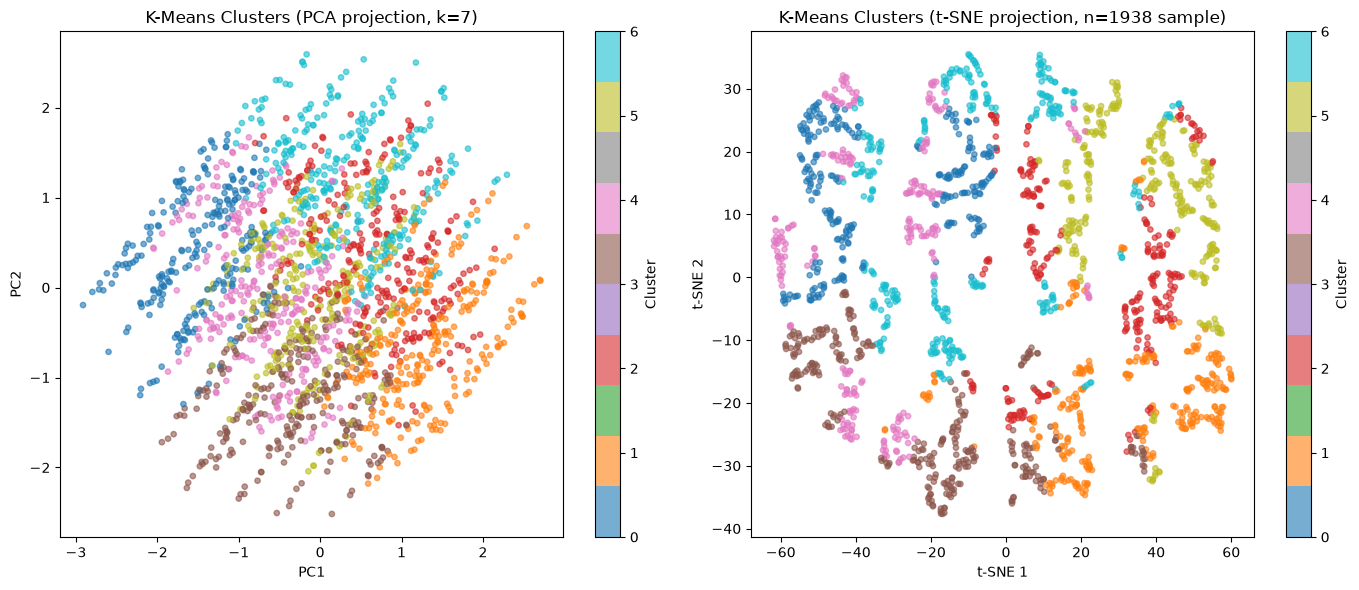

In [13]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_cluster)
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_} "
      f"(total: {pca.explained_variance_ratio_.sum():.2%})")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(pca_coords[:, 0], pca_coords[:, 1], c=cluster_df["cluster"],
                            cmap="tab10", s=15, alpha=0.6)
axes[0].set_title(f"K-Means Clusters (PCA projection, k={best_k})")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(scatter1, ax=axes[0], label="Cluster")

# t-SNE on a sample if the dataset is large, for reasonable runtime
sample_size = min(2000, len(X_cluster))
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_cluster), sample_size, replace=False)
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
tsne_coords = tsne.fit_transform(X_cluster[sample_idx])

scatter2 = axes[1].scatter(tsne_coords[:, 0], tsne_coords[:, 1],
                            c=cluster_df["cluster"].values[sample_idx], cmap="tab10", s=15, alpha=0.6)
axes[1].set_title(f"K-Means Clusters (t-SNE projection, n={sample_size} sample)")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
plt.colorbar(scatter2, ax=axes[1], label="Cluster")

plt.tight_layout()
plt.savefig("../reports/kmeans_pca_tsne.png", dpi=120)
plt.show()

## 8. Save models and log to MLflow

In [15]:
mlflow.set_tracking_uri("../mlruns")
mlflow.set_experiment("customer_support_regression")

# Log BOTH tuned models as separate runs, not just the winner - matches the
# logging pattern used everywhere else in this project (04/06/07/08 all log
# every model trained, not just the best one).
with mlflow.start_run(run_name="time_to_resolution_xgboost"):
    mlflow.log_params(xgb_study.best_params)
    mlflow.log_param("features", "tabular + TFIDF (leakage-free vectorizer)")
    mlflow.log_param("subset", "Closed tickets only")
    mlflow.log_param("n_train_samples", X_train.shape[0])
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_metric("cv_rmse", xgb_study.best_value)
    mlflow.log_metric("test_rmse", xgb_results["rmse"])
    mlflow.log_metric("test_mae", xgb_results["mae"])
    mlflow.log_metric("test_r2", xgb_results["r2"])
    mlflow.log_metric("mean_baseline_rmse", baseline_rmse)
    mlflow.log_metric("pct_resolution_before_first_response", pct_negative)
    mlflow.sklearn.log_model(xgb_model, "model")

with mlflow.start_run(run_name="time_to_resolution_lightgbm"):
    mlflow.log_params(lgb_study.best_params)
    mlflow.log_param("features", "tabular + TFIDF (leakage-free vectorizer)")
    mlflow.log_param("subset", "Closed tickets only")
    mlflow.log_param("n_train_samples", X_train.shape[0])
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_metric("cv_rmse", lgb_study.best_value)
    mlflow.log_metric("test_rmse", lgb_results["rmse"])
    mlflow.log_metric("test_mae", lgb_results["mae"])
    mlflow.log_metric("test_r2", lgb_results["r2"])
    mlflow.log_metric("mean_baseline_rmse", baseline_rmse)
    mlflow.log_metric("pct_resolution_before_first_response", pct_negative)
    mlflow.sklearn.log_model(lgb_model, "model")

mlflow.set_experiment("customer_support_clustering")
with mlflow.start_run(run_name=f"kmeans_k{best_k}"):
    mlflow.log_param("k", best_k)
    mlflow.log_param("features", CLUSTER_FEATURES)
    mlflow.log_param("n_samples", len(cluster_df))
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_metric("silhouette_score", final_silhouette)
    mlflow.log_metric("davies_bouldin_score", final_dbi)
    mlflow.log_artifact("../reports/kmeans_silhouette_by_k.png")
    mlflow.log_artifact("../reports/kmeans_pca_tsne.png")
    mlflow.sklearn.log_model(kmeans_model, "model")

joblib.dump(best_reg_model, f"../models/resolution_time_{best_reg_name.lower()}.joblib")
joblib.dump(kmeans_model, "../models/kmeans_segmentation.joblib")
joblib.dump(scaler, "../models/kmeans_scaler.joblib")
joblib.dump(label_encoders, "../models/label_encoders.joblib")

print("Logged XGBoost, LightGBM, and K-Means runs to MLflow, each with full hyperparameters and model artifact.")
print("Saved local copies to models/ as well.")

2026/09/13 12:26:19 WARNING mlflow.models.model: Input example should be provided to infer model signature if the model signature is not provided when logging the model.
2026/09/13 12:26:23 WARNING mlflow.models.model: Input example should be provided to infer model signature if the model signature is not provided when logging the model.
2026/09/13 12:26:26 WARNING mlflow.models.model: Input example should be provided to infer model signature if the model signature is not provided when logging the model.


Logged XGBoost, LightGBM, and K-Means runs to MLflow, each with full hyperparameters and model artifact.
Saved local copies to models/ as well.
